In [ ]:
from PIL import Image # Allowed ONLY for decoding the image to RGB [3]
import numpy as np
import matplotlib.pyplot as plt


def downscale(input_path, target_size=512):
    # 1. Decode the compressed image into raw RGB data
    img = Image.open(input_path).convert('RGB')
    pixels = img.load()
    orig_width, orig_height = img.size
    
    # Create a new blank 512x512 image array to act as our frame buffer
    out_img = Image.new('RGB', (target_size, target_size))
    out_pixels = out_img.load()
    
    # 2. Calculate the scaling ratios
    # This tells us how many pixels to "skip" in the original image 
    # for every 1 pixel in our new target image.
    x_ratio = orig_width / target_size
    y_ratio = orig_height / target_size
    
    # 3. Hand-crafted downscaling loop (Nearest Neighbor method)
    # We iterate exactly 512x512 times to fill our new frame
    for y in range(target_size):
        for x in range(target_size):
            
            # Map the 512x512 coordinates back to the original image's coordinates
            src_x = int(x * x_ratio)
            src_y = int(y * y_ratio)
            
            # Ensure we don't accidentally pull an index out of bounds
            src_x = min(src_x, orig_width - 1)
            src_y = min(src_y, orig_height - 1)
            
            # Extract the raw RGB values from the original pixel 
            # and map them to the new 512x512 output
            r, g, b = pixels[src_x, src_y] # type: ignore
            out_pixels[x, y] = (r, g, b) # type: ignore
            
    print(f"Successfully downscaled {orig_width}x{orig_height} to 512x512!")
    return out_img


In [3]:
# define utils

def convolution(image, kernel):
    # Get dimensions of the image and kernel
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape
    
    # Calculate padding for the image
    pad_height = kernel_height // 2
    pad_width = kernel_width // 2
    
    # Pad the image with zeros on the borders
    padded_image = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width)), mode='constant')
    
    # Prepare an output array to store the convolved result
    output = np.zeros_like(image)
    
    # Perform convolution
    for i in range(image_height):
        for j in range(image_width):
            # Extract the region of interest
            region = padded_image[i:i+kernel_height, j:j+kernel_width]
            # Apply the kernel to the region and sum the result
            output[i, j] = np.sum(region * kernel)
    
    return output

In [4]:
def rgb_to_hsv(rgb_image):
  # Normalize RGB values to [0, 1]
  rgb_normalized = rgb_image / 255.0
  r, g, b = rgb_normalized[:,:,0], rgb_normalized[:,:,1], rgb_normalized[:,:,2]
  
  cmax = np.max(rgb_normalized, axis=2)
  cmin = np.min(rgb_normalized, axis=2)
  delta = cmax - cmin
  
  # Hue calculation
  hue = np.zeros_like(cmax)
  hue[delta != 0] = np.where(cmax[delta != 0] == r[delta != 0], (g[delta != 0] - b[delta != 0]) / delta[delta != 0],
                              np.where(cmax[delta != 0] == g[delta != 0], (b[delta != 0] - r[delta != 0]) / delta[delta != 0] + 2,
                                        (r[delta != 0] - g[delta != 0]) / delta[delta != 0] + 4))
  hue = (hue * 60) % 360
  
  # Saturation calculation
  saturation = np.zeros_like(cmax)
  saturation[cmax != 0] = delta[cmax != 0] / cmax[cmax != 0]
  
  # Value calculation
  value = cmax
  
  return np.stack((hue, saturation, value), axis=2)

In [5]:
# sobel
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[1, 2, 1],
                    [0, 0, 0],
                    [-1, -2, -1]])

# combined xy
def combine_edge_xy(edge_x, edge_y):
    return np.sqrt(edge_x**2 + edge_y**2)

In [9]:
def threshold(image, thresh_value):
  # Create a binary image based on the threshold value
  binary_image = np.zeros_like(image)
  binary_image[image >= thresh_value] = 255
  return binary_image

In [10]:
# morphology, connect edges - pure implementation

# dilation
def dilation(image, structure=None):
  if structure is None:
    structure = np.ones((3, 3), dtype=np.uint8)  # Default to a 3x3 square structuring element
  
  # Pad the image to handle borders
  pad_height = structure.shape[0] // 2
  pad_width = structure.shape[1] // 2
  padded_image = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width)), mode='constant')
  
  dilated = np.zeros_like(image)
  
  for i in range(image.shape[0]):
    for j in range(image.shape[1]):
      # Extract the region of interest
      region = padded_image[i:i+structure.shape[0], j:j+structure.shape[1]]
      # If any pixel in the region is set and corresponds to the structuring element, set the output pixel
      if np.any(region * structure):
        dilated[i, j] = 255
  
  return dilated
  
# erosion
def erosion(image, structure=None):
  if structure is None:
      structure = np.ones((3, 3), dtype=np.uint8)  # Default to a 3x3 square structuring element
  
  # Pad the image to handle borders
  pad_height = structure.shape[0] // 2
  pad_width = structure.shape[1] // 2
  padded_image = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width)), mode='constant')
  
  eroded = np.zeros_like(image)
  
  for i in range(image.shape[0]):
    for j in range(image.shape[1]):
      # Extract the region of interest
      region = padded_image[i:i+structure.shape[0], j:j+structure.shape[1]]
      # If all pixels in the region that correspond to the structuring element are set, set the output pixel
      if np.all(region * structure):
        eroded[i, j] = 255
  
  return eroded

# closing
def morphological_closing(image, structure=None):
  if structure is None:
    structure = np.ones((3, 3), dtype=np.uint8)  # Default to a 3x3 square structuring element
  
  # Dilation
  dilated = dilation(image, structure)
  
  # Erosion
  closed = erosion(dilated, structure)
  
  return closed

# opening
def morphological_opening(image, structure=None):
  if structure is None:
    structure = np.ones((3, 3), dtype=np.uint8)  # Default to a 3x3 square structuring element
  
  # Erosion
  eroded = erosion(image, structure)
  
  # Dilation
  opened = dilation(eroded, structure)
  
  return opened

In [11]:
def extract_segments(edges, threshold=50):
    h, w = edges.shape
    visited = np.zeros((h, w), dtype=bool)

    segments = []

    for y in range(h):
        for x in range(w):

            if edges[y, x] > threshold and not visited[y, x]:

                stack = [(y, x)]
                segment = []

                visited[y, x] = True

                while stack:
                    cy, cx = stack.pop()
                    segment.append((cy, cx))

                    for ny, nx in [
                        (cy-1,cx),(cy+1,cx),(cy,cx-1),(cy,cx+1),
                        (cy-1,cx-1),(cy-1,cx+1),(cy+1,cx-1),(cy+1,cx+1)
                    ]:
                        if 0 <= ny < h and 0 <= nx < w:
                            if edges[ny,nx] > threshold and not visited[ny,nx]:
                                visited[ny,nx] = True
                                stack.append((ny,nx))

                segments.append(segment)

    return segments

Successfully downscaled 4096x3072 to 512x512!


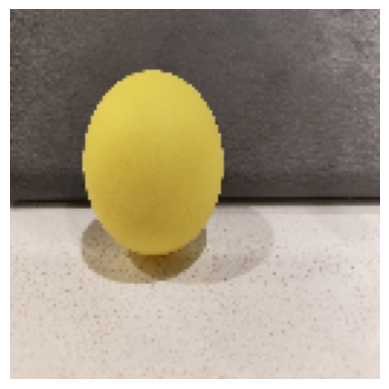

In [2]:
import numpy as np
import matplotlib.pyplot as plt

img = np.array(downscale("frame1.jpg", 128))

# show img
plt.imshow(img)
plt.axis('off')
plt.show()

Successfully downscaled 4096x3072 to 512x512!


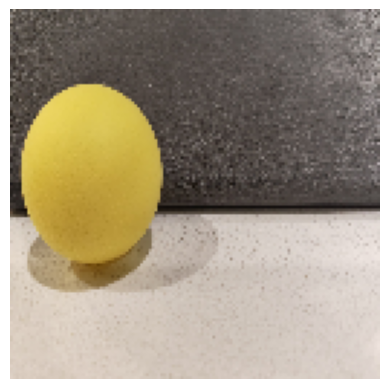

In [ ]:
img2 = np.array(downscale("frame2.jpg", 128))

# show img
plt.imshow(img2)
plt.axis('off')
plt.show()

[[(20, 44), (21, 45), (22, 46), (21, 47), (22, 48), (21, 49), (22, 50), (21, 51), (22, 52), (21, 53), (22, 54), (23, 55), (22, 56), (23, 57), (24, 58), (25, 59), (26, 60), (27, 61), (26, 62), (27, 63), (28, 64), (29, 65), (30, 66), (31, 67), (32, 68), (33, 69), (34, 70), (35, 69), (36, 70), (37, 71), (38, 70), (39, 71), (40, 72), (41, 71), (42, 72), (43, 73), (44, 72), (45, 73), (46, 74), (47, 73), (48, 74), (49, 73), (50, 74), (51, 73), (52, 74), (53, 73), (54, 74), (55, 73), (56, 74), (57, 75), (58, 74), (59, 73), (60, 74), (61, 73), (62, 74), (63, 73), (64, 74), (65, 75), (66, 76), (67, 77), (68, 78), (67, 79), (68, 80), (67, 81), (68, 82), (67, 83), (68, 84), (67, 85), (68, 86), (67, 87), (68, 88), (67, 89), (68, 90), (67, 91), (68, 92), (67, 93), (68, 94), (67, 95), (68, 96), (67, 97), (68, 98), (67, 99), (68, 100), (67, 101), (68, 102), (67, 103), (68, 104), (67, 105), (68, 106), (67, 107), (68, 108), (67, 109), (68, 110), (67, 111), (68, 112), (67, 113), (68, 114), (67, 115), (6

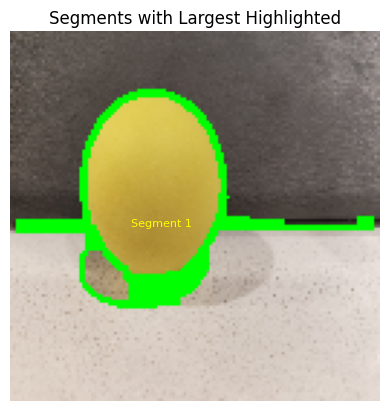

In [19]:
# Edges
sobel_x_result = convolution(rgb_to_hsv(img)[:,:,1], sobel_x)
sobel_y_result = convolution(rgb_to_hsv(img)[:,:,1], sobel_y)
edges = combine_edge_xy(sobel_x_result, sobel_y_result)
edges = threshold(edges, edges.mean() + edges.std())
edges = morphological_closing(edges, structure=np.ones((5, 5), dtype=np.uint8))

# segments
segments = extract_segments(edges)

print(segments)

# Largest segment
largest_segment = max(segments, key=len)

# display all segments w/ largest segment having a different color, w/ radius of each segment, overlayed on image opacity 80

overlay = img.copy()
for i, segment in enumerate(segments):
    # text on center
    center_y = sum(p[0] for p in segment) // len(segment)
    center_x = sum(p[1] for p in segment) // len(segment)
    plt.text(s=f"Segment {i+1}", x=center_x, y=center_y, color='yellow', fontsize=8, ha='center', va='center')

    for y, x in segment:
        overlay[y, x] = [255, 0, 0]  # Red for all segments

for y, x in largest_segment:
    overlay[y, x] = [0, 255, 0]  # Green for largest segment
plt.imshow(overlay)
plt.title('Segments with Largest Highlighted')
plt.axis('off')
plt.show()

[[(2, 8), (3, 8)], [(22, 2), (23, 3), (24, 2), (25, 3), (25, 2), (22, 4), (23, 4), (24, 3), (22, 3), (23, 2)], [(25, 21), (26, 22), (27, 23), (26, 24), (25, 25), (26, 26), (25, 27), (26, 28), (25, 29), (26, 30), (27, 31), (26, 32), (27, 33), (26, 34), (27, 35), (28, 36), (29, 37), (30, 38), (29, 39), (30, 40), (31, 41), (32, 42), (33, 43), (34, 44), (35, 45), (36, 46), (37, 47), (38, 48), (39, 49), (40, 48), (41, 49), (42, 50), (43, 51), (44, 50), (45, 51), (46, 52), (47, 51), (48, 52), (49, 51), (50, 52), (51, 51), (52, 52), (53, 53), (54, 52), (55, 53), (56, 54), (57, 55), (58, 56), (59, 57), (60, 58), (61, 59), (62, 60), (63, 61), (64, 62), (65, 63), (66, 64), (67, 65), (68, 66), (69, 67), (70, 68), (71, 69), (70, 70), (71, 71), (70, 72), (71, 73), (70, 74), (71, 75), (70, 76), (71, 77), (70, 78), (71, 79), (70, 80), (71, 81), (70, 82), (71, 83), (70, 84), (71, 85), (70, 86), (71, 87), (70, 88), (71, 89), (70, 90), (71, 91), (70, 92), (71, 93), (70, 94), (71, 95), (70, 96), (71, 97)

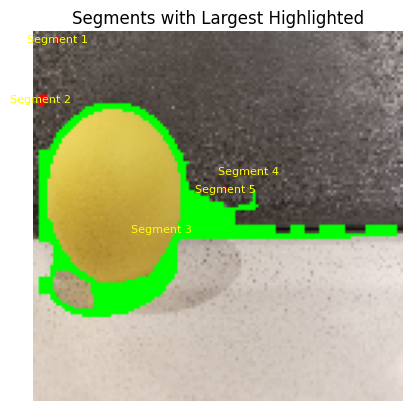

In [27]:
# Edges
sobel_x_result = convolution(rgb_to_hsv(img2)[:,:,1], sobel_x)
sobel_y_result = convolution(rgb_to_hsv(img2)[:,:,1], sobel_y)
edges = combine_edge_xy(sobel_x_result, sobel_y_result)
edges = threshold(edges, edges.mean() + edges.std())
edges = morphological_closing(edges, structure=np.ones((5, 5), dtype=np.uint8))

# segments
segments = extract_segments(edges)

print(segments)

# Largest segment
largest_segment = max(segments, key=len)

# display all segments w/ largest segment having a different color, w/ radius of each segment, overlayed on image opacity 80

overlay = img2.copy()
for i, segment in enumerate(segments):
    # text on center
    center_y = sum(p[0] for p in segment) // len(segment)
    center_x = sum(p[1] for p in segment) // len(segment)
    plt.text(s=f"Segment {i+1}", x=center_x, y=center_y, color='yellow', fontsize=8, ha='center', va='center')

    for y, x in segment:
        overlay[y, x] = [255, 0, 0]  # Red for all segments

for y, x in largest_segment:
    overlay[y, x] = [0, 255, 0]  # Green for largest segment
plt.imshow(overlay)
plt.title('Segments with Largest Highlighted')
plt.axis('off')
plt.show()